# DS_PROD-3. Сервисная архитектура и оркестрация приложений

## 1. Введение

Добро пожаловать в заключительный модуль из раздела «ML в Production»!

В предыдущих модулях мы научились производить сериализацию и десериализацию моделей, разворачивать собственные простейшие веб-сервисы, создавать для них виртуальные окружения и контейнеризировать их.

В этом модуле нам понадобятся полученные ранее знания, поэтому давайте освежим их, выполнив несколько заданий.

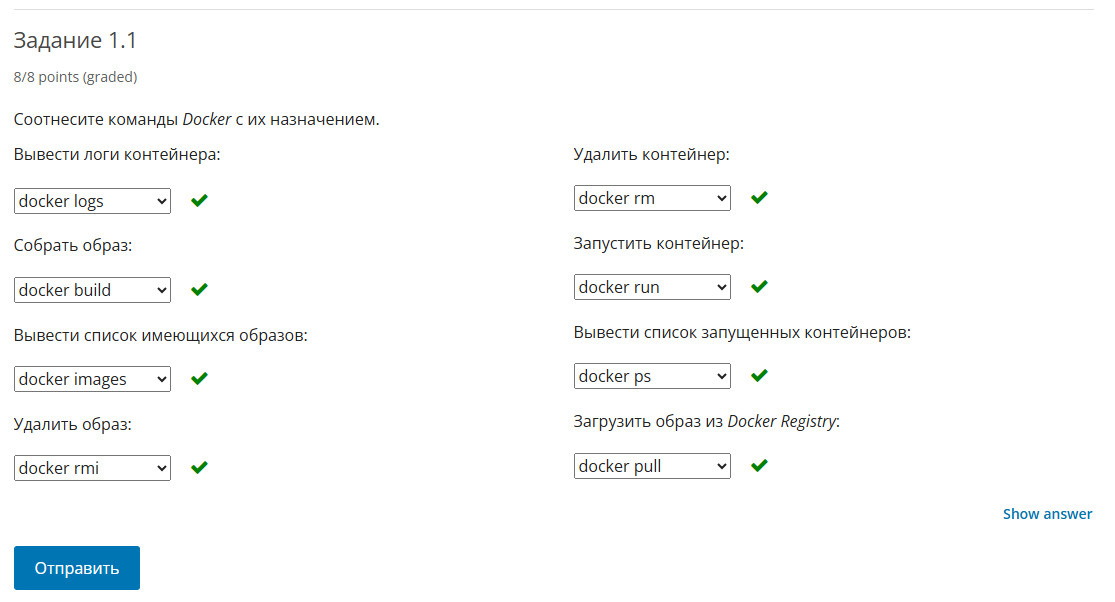

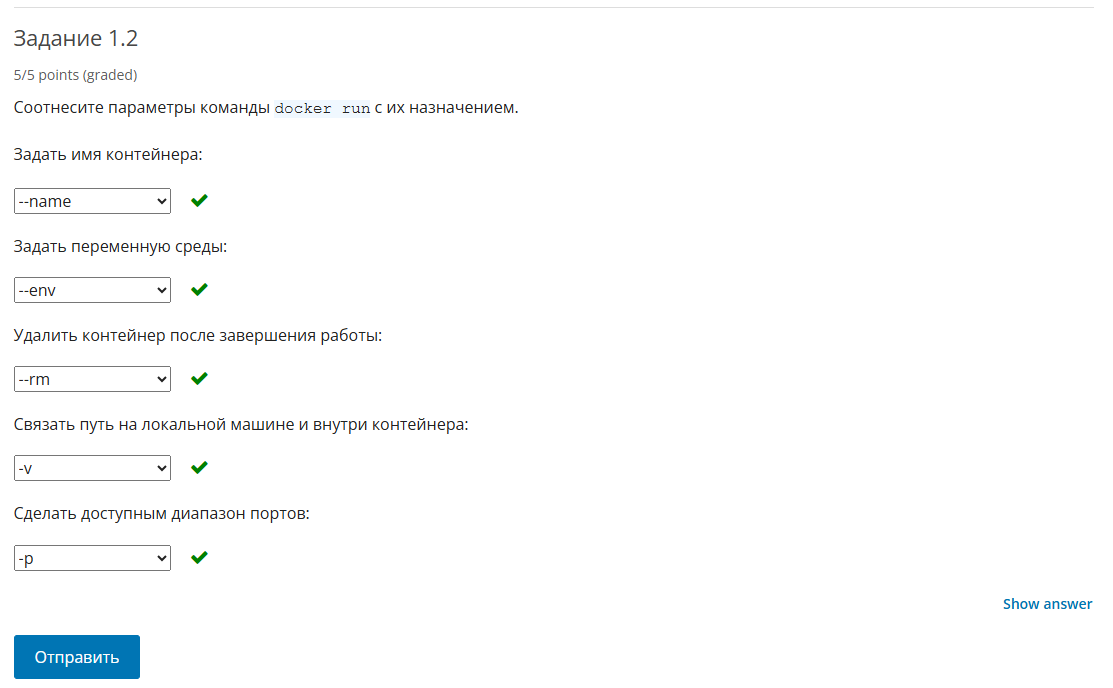

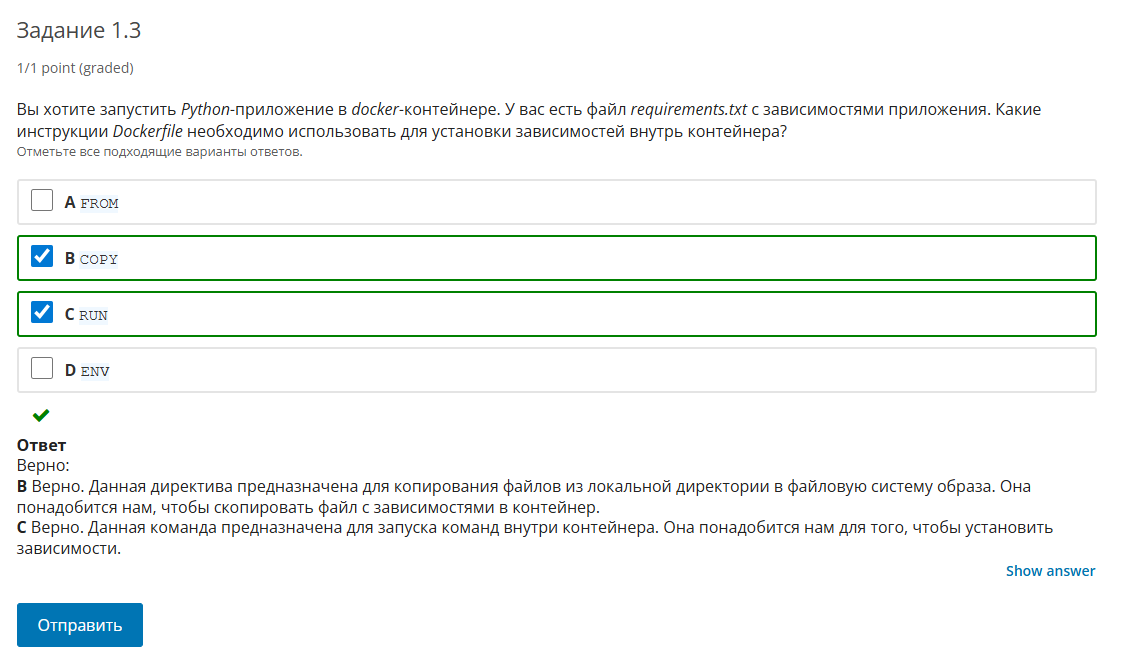

**Микросервисная архитектура приложения.**

В основной части модуля мы поговорим о двух подходах к построению архитектуры приложения (монолитный и микросервисный), рассмотрим их плюсы и минусы и обсудим, когда нужно использовать тот или иной подход.

Затем мы перейдём к обсуждению микросервисного подхода и разберём, какие существуют варианты организации взаимодействия между сервисами и какие инструменты помогают решать эти задачи.

В качестве практики мы организуем вокруг модели машинного обучения несколько микросервисов, которые будут взаимодействовать через очередь RabbitMQ.

После этого мы разместим наши сервисы в docker-контейнерах и придём к понятию оркестрации. С помощью инструмента оркестрации Docker Compose мы создадим небольшое микросервисное приложение, в котором каждый сервис будет работать внутри контейнера.

**Инструменты управления жизненным циклом модели.**

В этой части модуля мы поговорим о современных инструментах, которые можно использовать для управления жизненным циклом модели, а именно о DVC и MLflow.

**Оценка бизнес-эффективности.**

В заключительной части модуля мы поговорим о том, как можно оценить эффективность построенных нами моделей машинного обучения с точки зрения бизнеса, какие существуют бизнес-метрики, и обсудим, какие трудности могут нас ожидать.

### Цели модуля:

- узнать, какие виды сервисной архитектуры существуют и в чём их особенности;

- научиться настраивать взаимодействие между сервисами с помощью очередей;

- узнать, что такое брокер сообщений и для чего он нужен;

- понять, как можно отслеживать работу сервиса или группы сервисов;

- познакомиться с термином «оркестрация» и узнать, почему она необходима при микросервисной архитектуре;

- научиться работать с Docker Compose;

- рассмотреть несколько инструментов, которые могут помочь на различных этапах жизненного цикла модели;

- узнать, как оценивать эффективность полученных моделей с точки зрения бизнес-эффекта.

Давайте приступим.

# 2. Монолитная и микросервисная архитектуры. Брокеры и очереди

Требования продакшн-среды влияют и на выбор архитектуры. Существует два её основных типа: монолитная и микросервисная.

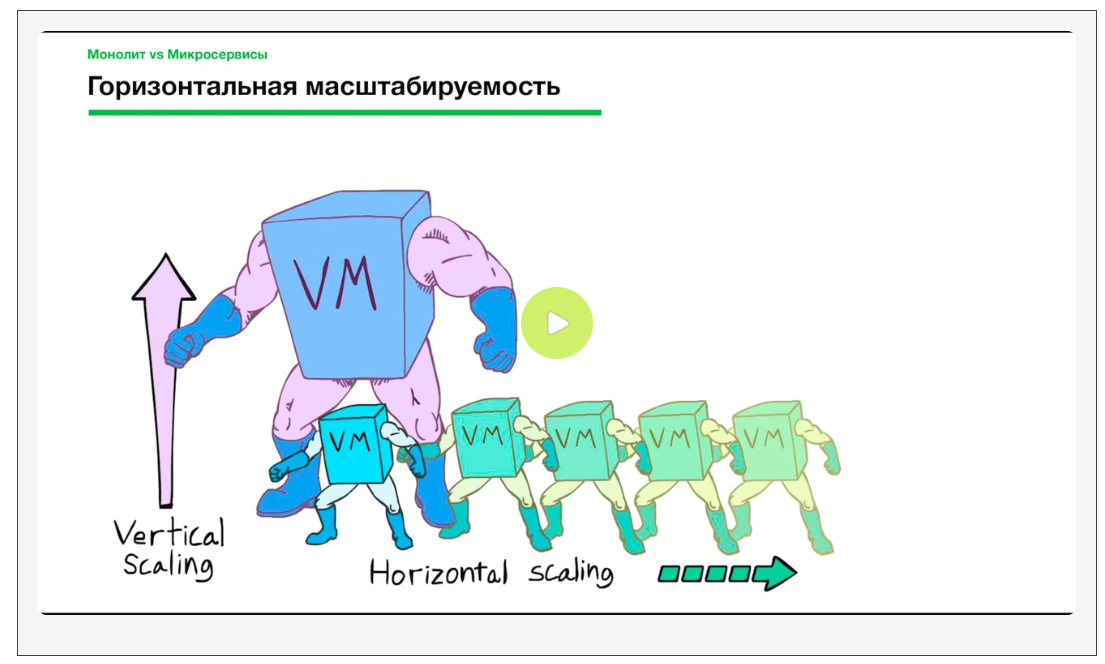

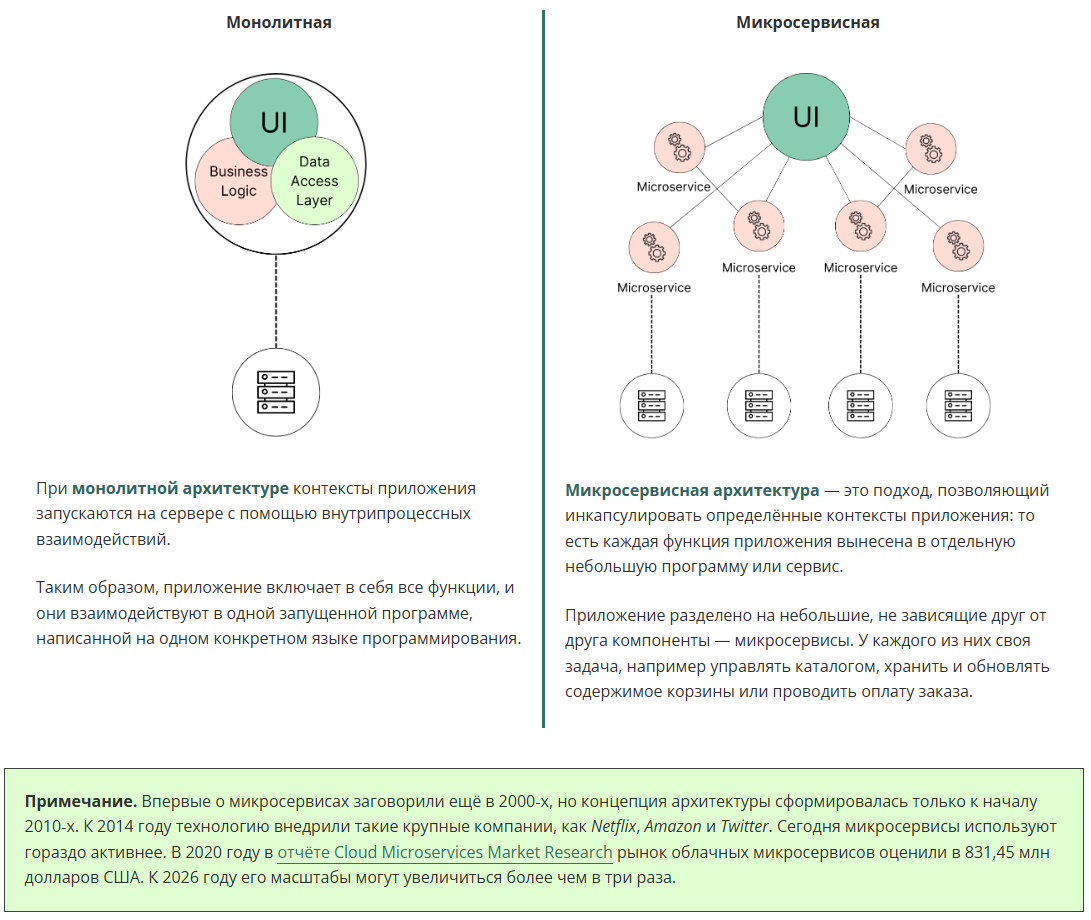

### ПРЕИМУЩЕСТВА И НЕДОСТАТКИ МИКРОСЕРВИСНОГО ПОДХОДА В РАЗРАБОТКЕ

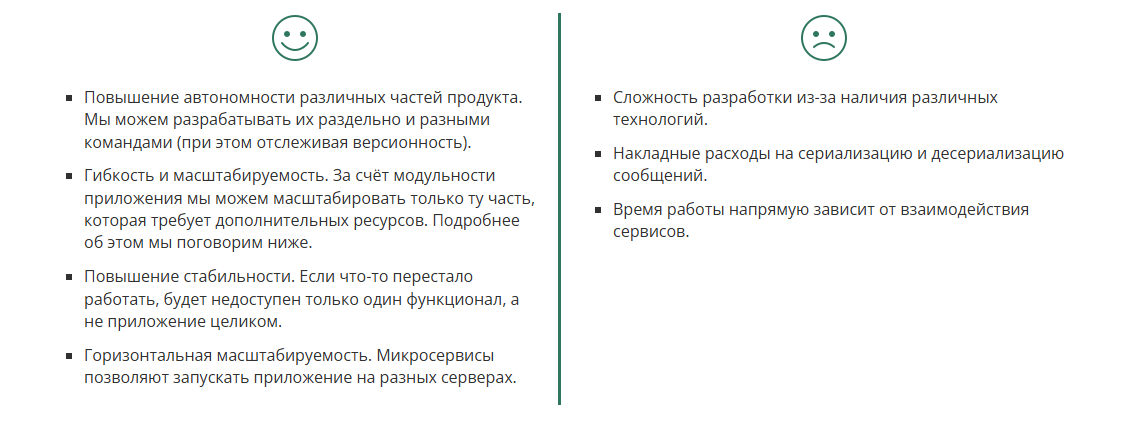

### МАСШТАБИРУЕМОСТЬ СИСТЕМЫ

По мере роста и развития приложения, увеличения числа пользователей и данных у команды неизбежно возникают вопросы:

1. Как обрабатывать N запросов в секунду? Как уменьшить время обработки одного запроса?
2. Как и в чём хранить постоянно увеличивающийся в объёме поток данных от пользователей?
3. Как подстраховаться от падения БД (ведь это трата времени и, следовательно, потеря денег)?
4. Как добиться высокой степени доступности приложения для всех пользователей?
5. Что делать с тяжёлыми запросами, которые могут выполняться часами?

Обобщая эти и подобные вопросы, говорят о **масштабируемости** системы — её способности выдерживать рост нагрузки по мере добавления ресурсов.

Давайте разберёмся в этом подробнее. При создании действительно крупных приложений существует два подхода:

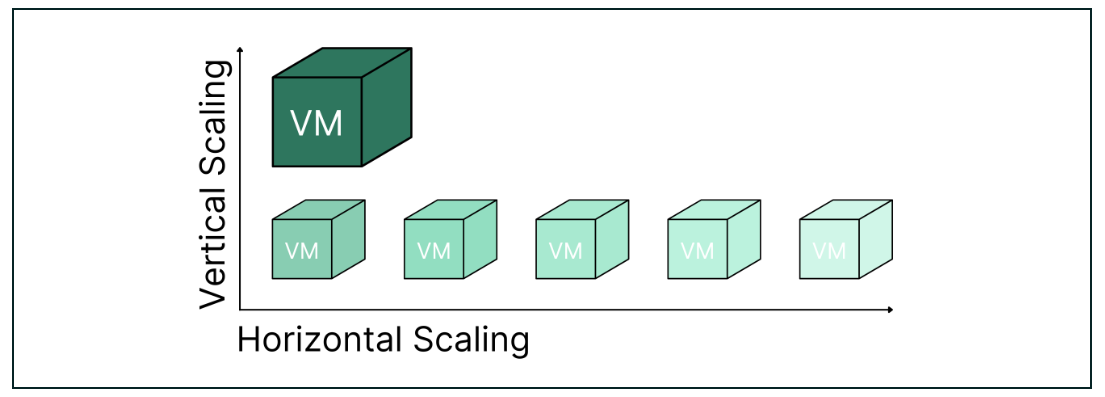

- **Вертикальное масштабирование** (scale up): заменить сервер сервером с большей вместимостью и мощностью. Как вы понимаете, у всего есть предел.
- **Горизонтальное масштабирование** (scale out): добавить ещё один сервер и объединить серверы в кластер.

Идеальный вариант — добиться **линейной зависимости**, то есть сделать так, чтобы при добавлении ресурсов приложение выдерживало прямо пропорциональный рост нагрузки. Однако такое встречается редко из-за неоптимальной работы разных частей системы: так, добавление дополнительного сервера, обрабатывающего запросы, может увеличить параметр максимальной нагрузки в два раза, а вот добавление ещё двух серверов вряд ли увеличит этот параметр в четыре раза.

### Что мы можем сделать для лучшего масштабирования системы?

1. **Добавить балансировщики нагрузки** перед дублирующими друг друга серверами. Эти балансировщики будут отправлять запросы на те серверы, на которых нагрузка меньше, чем на остальных.

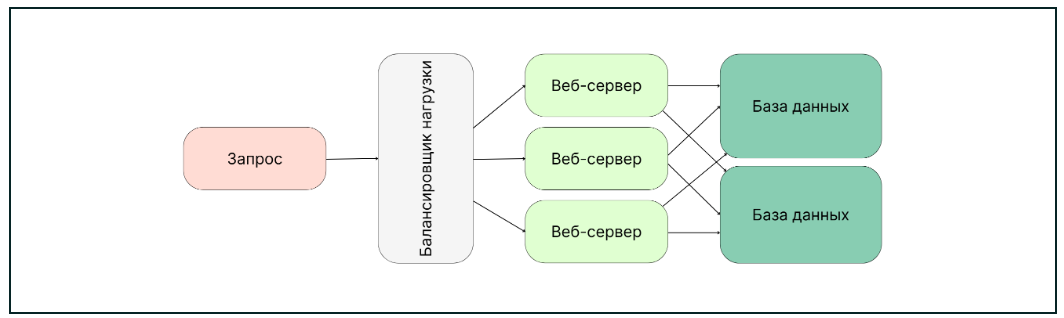

2. **Добавить кэш** — быстрый «буфер» между базой данных и приложением. В таком случае диспетчер сначала проверит в кэше, не выполнялся ли аналогичный запрос раньше, и только потом направит его на сервер.

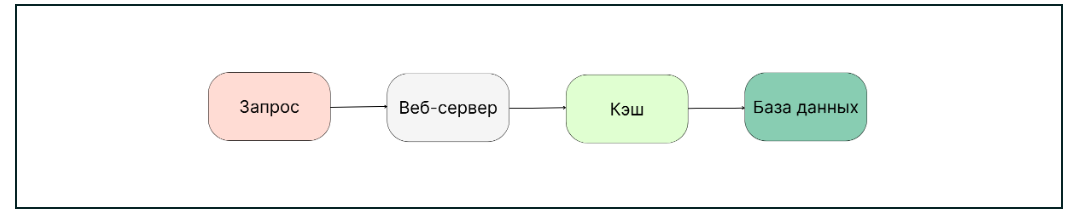

3. **Оптимизировать работу БД:**

- скопировать БД, чтобы застраховаться от её падения;
- денормализовать данные, чтобы все поля содержались в одной таблице — так мы избежим дополнительной нагрузки на объединение данных;
- оптимизировать SQL-запросы, повысив скорость их обработки.

4. **Добавить асинхронные очереди сообщений** между частями системы. Подробнее об асинхронном взаимодействии сервисов мы поговорим в следующем блоке.



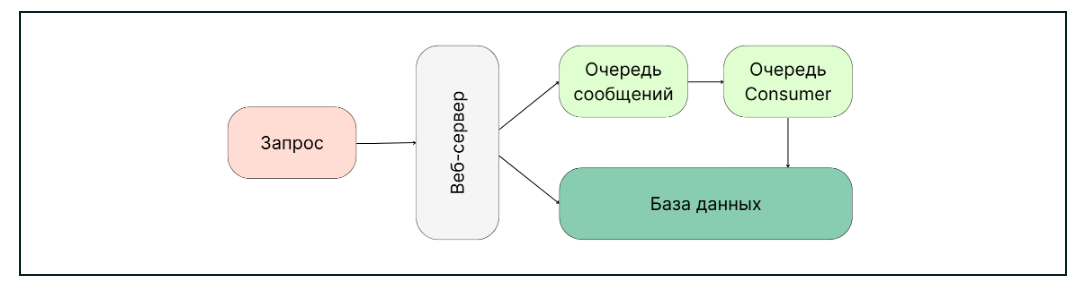

### КОГДА ИСПОЛЬЗОВАТЬ МИКРОСЕРВИСНУЮ АРХИТЕКТУРУ?

Выбор архитектуры должен основываться на понимании всех требований к разрабатываемому приложению.

Разработчики Яндекс составили небольшой перечень критериев, по которым вы можете понять, подходит ли вашему проекту микросервисная архитектура. Если ваш проект соответствует хотя бы одному пункту из этого списка, задумайтесь об использовании микросервисов. https://cloud.yandex.ru/blog/posts/2022/03/microservice-architecture

**- Большие коллективы.**

Микросервисы позволяют группам разработчиков не задумываться о синхронизации каждого шага: каждая команда может работать над одним или несколькими микросервисами и использовать свои инструменты.

Новые фичи можно разрабатывать параллельно и запускать по мере готовности.

**- Объёмные проекты со сложной архитектурой.**

Обновлять и поддерживать отдельные модули крупных систем намного проще, чем контролировать, как изменения скажутся на системе в целом.

**- Продукты с резко меняющимся трафиком.**

Если вашим продуктом начинают чаще пользоваться в период праздников или распродаж, микросервисы позволят вам быстро масштабироваться и уменьшить риск отказа системы. Кроме того, вам не придётся платить за дополнительную инфраструктуру, которая нужна только в периоды пиковых нагрузок.

**- Приложения, требующие частых обновлений.**

Достаточно изменить и отладить только тот модуль, который вы хотите обновить. Это существенно сокращает время разработки и приближает релиз.

Однако главный вопрос, который вам стоит задать себе, прежде чем погружаться в мир микросервисов: можно ли разделить ваш продукт на простые независимые части? Хороший микросервис должен быть легковесным, автономным, обходиться собственной изолированной базой данных и решать одну конкретную бизнес-задачу.

Если ваш проект можно разделить на такие самостоятельные составные части, то вы можете смело выбирать микросервисы в качестве архитектуры своего приложения.

### ВЗАИМОДЕЙСТВИЕ МЕЖДУ СЕРВИСАМИ

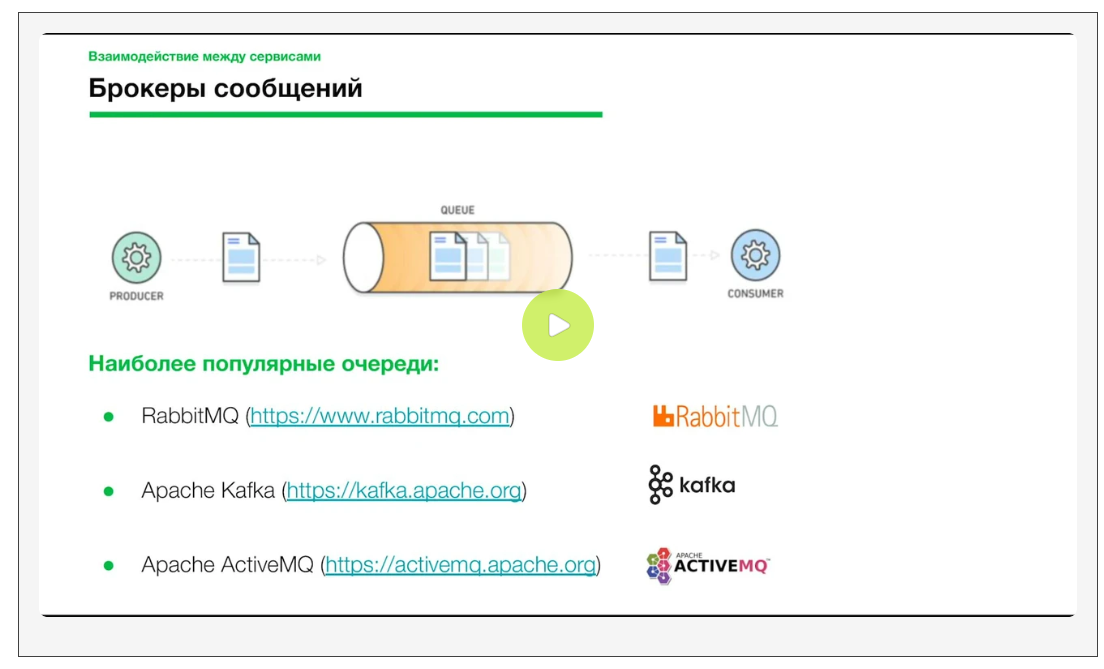

Как мы уже поняли, при создании микросервисной архитектуры требуется **организация обмена данными между сервисами**.

Давайте разберёмся, какие существуют типы организации взаимодействия сервисов:

**Синхронный**

Один сервис обращается к другому и ожидает ответа.

Для организации синхронного взаимодействия используется протокол HTTP или HTTPS. Сервисы обмениваются данными через HTTP-запросы.

Разработка и отладка просты, однако сервис должен быть постоянно доступен — в противном случае обмен сообщениями остановится.

**Асинхронный**

Сервисы взаимодействуют между собой путём передачи сообщений. Таким образом, сервис не ожидает ответ, а продолжает работу. Нужный сервис принимает сообщение и начинает его обработку.

Для организации асинхронного взаимодействия используются очереди сообщений. О них мы поговорим ниже.

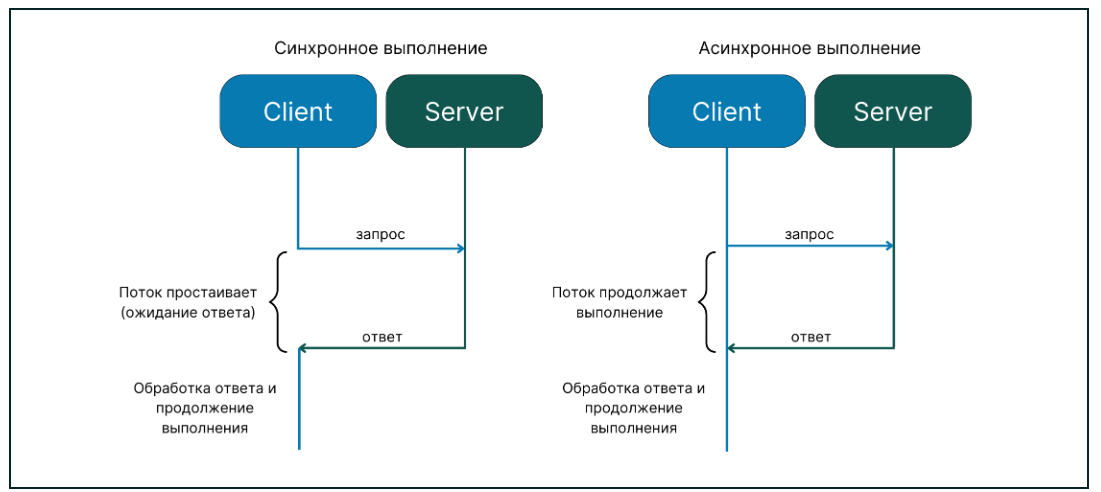

### БРОКЕРЫ СООБЩЕНИЙ

Брокеры сообщений (также их называют **диспетчеры очереди**) помогают организовать межсистемный обмен сообщениями и являются связующим звеном между различными процессами в приложениях.

Как правило, в таких системах используется паттерн проектирования **«издатель → очередь → подписчик»** (producer → queue → consumer). Под издателем и подписчиком здесь можно понимать всё что угодно (например, микросервисы или целые приложения), то есть это абстрактные понятия, не привязанные к конкретной реализации.

Издатель отправляет сообщение на брокер сообщений, который помещает полученное сообщение в очередь. На одном брокере может быть запущено несколько очередей, например очередь запросов, очередь ответов и служебная очередь, в которую записываются служебные сообщения (логи). После этого сообщение извлекается из очереди и передаётся подписчику.

Издателей и подписчиков может быть несколько, и они могут взаимодействовать друг с другом через очереди в асинхронном режиме, то есть им не нужно останавливать свой процесс работы в ожидании ответного сообщения.

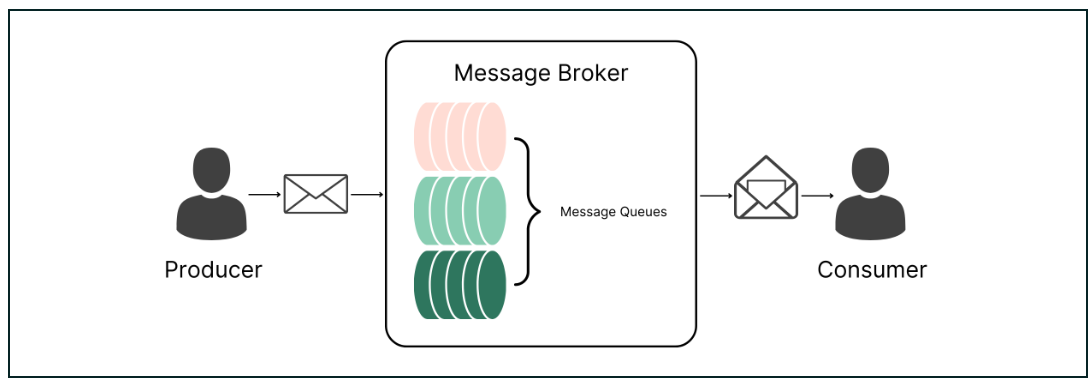

Благодаря брокерам сообщений отправителю не нужно ничего знать о потребителе или потребителях, поэтому связь между сервисами значительно упрощается. Однако поддержка инфраструктуры с участием очереди становится немного сложнее.

Чтобы обеспечить хранение сообщений в очереди до момента их прочтения получателем, доступ к очереди должен быть **асинхронным**.

Структура данных очереди представлена следующими правилами:

- первым «читается» сообщение, пришедшее первым;
- новые элементы добавляются только в конец очереди;
- чтение и удаление происходит только из начала очереди.

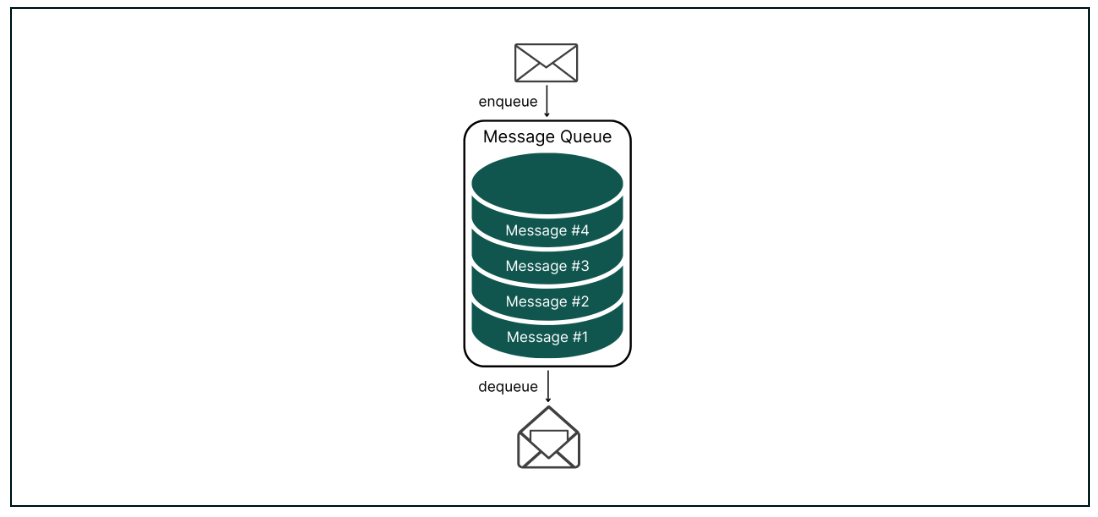

Кроме того, для организации очереди необходимо определиться с форматом сообщений (например, XML или JSON). Однако это сильно зависит от типа реализации очереди — бывают случаи, когда определять формат нет необходимости.

**Пример, когда может понадобиться использование очередей**

На веб-сервере функционирует огромная нейронная сеть или другая крупная модель. Если клиенты будут отправлять свои данные (например, изображения), а сервер будет принимать эти запросы и обрабатывать данные, подавая их в модель, то время задержки на обработку каждого запроса будет очень большим.

Поэтому идея следующая: пусть сервер — это отдельный микросервис. Назовём его server (это обычное веб-приложение, реализованное, например, через стек Flask + uWSGI + NGINX). Этот микросервис решает одну задачу: принимает сообщения от клиентов, присваивает им идентификаторы, но не обрабатывает их, а помещает в очередь обработки (назовём её data).

Для прогона данных через модель будет реализован отдельный микросервис (назовём его model). Внутри него тоже может быть что угодно, например нейронная сеть, которая проводит сегментацию изображений. Этот микросервис извлекает сообщения с данными от пользователя из очереди, обрабатывает их моделью и отправляет в другую очередь (назовём её predictions).

Сервер в фоновом режиме просматривает очередь predictions и, если в ней появилось новое сообщение (предсказание модели), извлекает его и отправляет нужному клиенту.

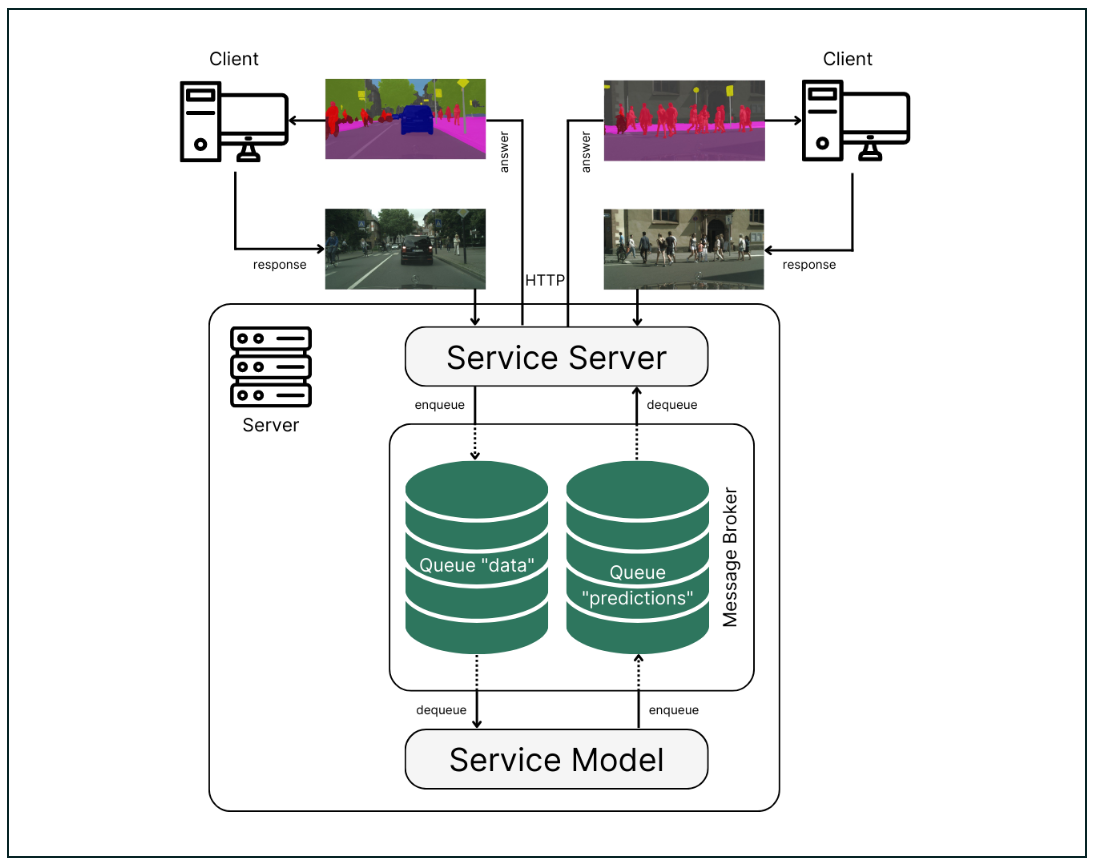

Наиболее популярны следующие программные реализации очереди:

- RabbitMQ, https://www.rabbitmq.com/
- Apache Kafka, https://kafka.apache.org/
- ActiveMQ. https://activemq.apache.org/

Чтобы понять принципы работы с очередями сообщений и сериализацией, мы разберём диспетчер сообщений RabbitMQ. Он прост в использовании, максимально эффективен, работает на разных системах и пользуется большой популярностью.

Примечание. Также стоит отметить, что с помощью протокола HTTP возможно организовать не только синхронное, но и асинхронное взаимодействие, однако эта тема выходит за рамки нашего курса.

# 3. Организация взаимодействия через очереди. RabbitMQ

В этом модуле мы рассмотрим основные концепции работы с брокером очередей RabbitMQ: мы создадим несколько микросервисов на Python и организуем их асинхронное взаимодействие через этот брокер.

Сначала мы рассмотрим основную терминологию, которая пригодится нам в работе с RabbitMQ, а затем перейдём к реализации взаимодействия сервисов.

Как вы помните, объект из памяти одного процесса нельзя напрямую перенести в память другого, поскольку объект может иметь сложную структуру и быть разбит на фрагменты в оперативной памяти. Чтобы сохранить целостность объекта, применяется **сериализация**.

При сохранении и загрузке моделей мы проводим эти операции один раз, поэтому это не увеличивает нагрузку на процессы. Для организации взаимодействия сервисов необходимо **сериализовывать** каждое сообщение (например, вектор входных данных) при его отправке, **десериализовывать** его после получения в сервисе для подачи в модель и уже после преобразовывать его в поток битов предсказания. Это требует ресурсов.

Совет. Если добавить сжатие данных, то потребуется больше ресурсов CPU на их чтение и запись, но сам объём данных будет меньше. Таким образом мы уменьшим нагрузку на сеть и диск.

Для взаимодействия между сервисами чаще всего используется уже знакомый вам формат JSON.

Вы можете освежить свои знания по формату JSON модуле «PY-16. Как выгружать данные из различных форматов». Для работы с этим форматом используется библиотека json, которая очень похожа на pickle.

Для примера работы с брокером очередей мы возьмём интеграцию RabbitMQ и Docker (https://www.docker.com/why-docker/). Для подключения наших процессов к очереди будем использовать библиотеку pika. Давайте разберёмся, как это работает.

### ОСНОВЫ РАБОТЫ С RABBITMQ. AMQP

RabbitMQ — это брокер сообщений, основная цель которого — принимать и отдавать сообщения.

Можете представить себе RabbitMQ как почтовое отделение: когда вы опускаете письмо в ящик, вы можете быть уверены, что рано или поздно почтальон доставит его адресату. В этой аналогии RabbitMQ является одновременно и почтовым ящиком, и почтовым отделением, и почтальоном.

Отличие RabbitMQ от почтового отделения в том, что он не имеет дела с бумажными конвертами, а принимает, хранит и отдаёт сообщения в бинарном (сериализованном) виде.

RabbitMQ использует протокол AMQP (Advanced Message Queuing Protocol) https://www.rabbitmq.com/tutorials/amqp-concepts.

**Протокол AMQP** — открытый стандарт передачи сообщений. Он позволяет подсистемам/независимым приложениям обмениваться сообщениями через AMQP-брокер, отвечающий за маршрутизацию, доставку сообщений, распределение нагрузки и так далее.

Основная терминология AMQP:

1. Message (сообщение) — передаваемые данные.
2. Exchange (точка обмена) — механизм маршрутизации сообщений. Точка обмена получает сообщения и распределяет их по очередям (одно сообщение может уйти в одну или несколько очередей), но при этом сама она не хранит сообщения. В самом простом случае для маршрутизации сообщений используется ключ (routing key), равный названию очереди, в которую нужно отправить сообщение. Иными словами, routing key — это виртуальный адрес очереди.
3. Bindings (правила распределения) — правила, по которым точка обмена определяет, куда именно нужно отправить пришедшее сообщение.
4. Queue (очередь) хранит сообщения до тех пор, пока какой-нибудь AMQP-клиент не заберёт их.
5. Producer (издатель) — клиент, публикующий сообщения в exchange.
6. Consumer (подписчик) — клиент, получающий сообщения из очередей.
7. Connection (соединение) — служит для физического сетевого соединения между клиентом и брокером и объединения нескольких каналов.
8. Channel (канал) — используется для логического соединения между клиентом и брокером.

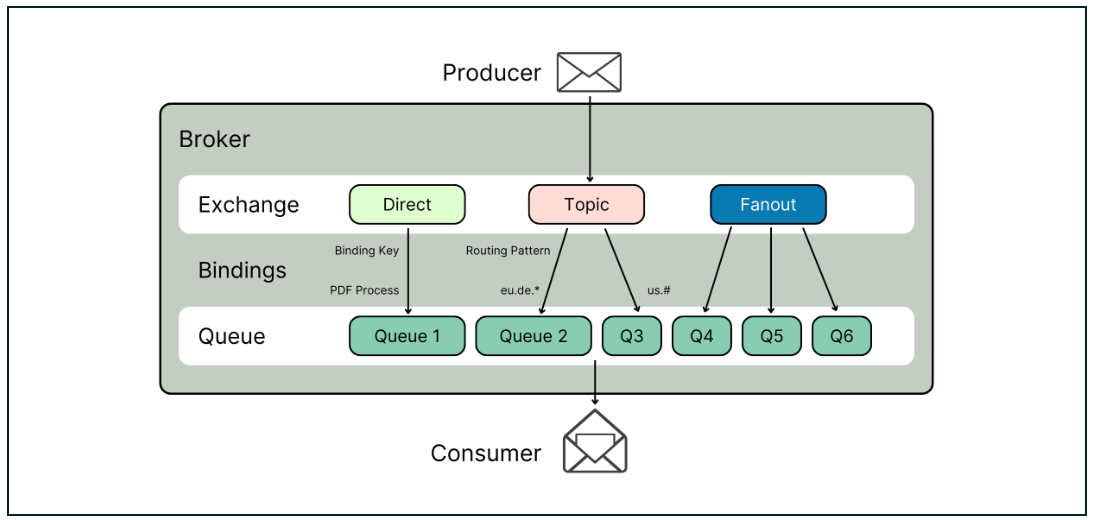

Примечание. Более подробно о принципах работы протокола AMQP можно узнать здесь.https://habr.com/post/62502/

Чтобы реализовать AMQP на Python, мы воспользуемся библиотекой pika https://pika.readthedocs.io/en/stable/. Мы выбрали эту библиотеку, поскольку она подойдёт для любого брокера, который работает по протоколу AMQP.

Основные функции библиотеки, с которыми мы будем работать:

- BlockingConnection — объявление соединения;
- channel — объявление канала;
- queue_declare — объявление очереди;
- basic_publish — отправка сообщения;
- basic_consume — получение сообщения;
- callback — метод, вызываемый при получении сообщения.

### УСТАНОВКА ИНСТРУМЕНТОВ

**Шаг 0. Установка Docker.**

Этот шаг вы выполняли ещё в прошлом модуле.

**Шаг 1. Установка RabbitMQ.**

Теперь, когда Docker уже есть в нашей системе, достаточно просто включить брокер сообщений RabbitMQ — он находится в Docker Registry в виде образа rabbitmq. Мы будем пользоваться версией 3-management. Давайте запустим docker-контейнер на основе этого образа:

In [ ]:
$ docker run -it --rm --name rabbitmq -p 5672:5672 -p 15672:15672 rabbitmq:3-management

Здесь:

- -p 5672:5672 — порт для доступа к очереди;
- -p 15672:15672 — порт для доступа к пользовательскому интерфейсу RabbitMQ.

После выполнения команды на экране появится большое информационное сообщение и брокер уйдёт в режим ожидания сообщений.

Наша очередь работает и готова к приёму сообщений — к ней можно обратиться по адресу localhost:5672.

Примечание. Вы можете войти в режим графического интерфейса управления RabbitMQ. Для этого перейдите по адресу http://localhost:15672. В результате откроется окно графического интерфейса RabbitMQ, с помощью которого вы можете управлять очередями и другими компонентами RabbitMQ.

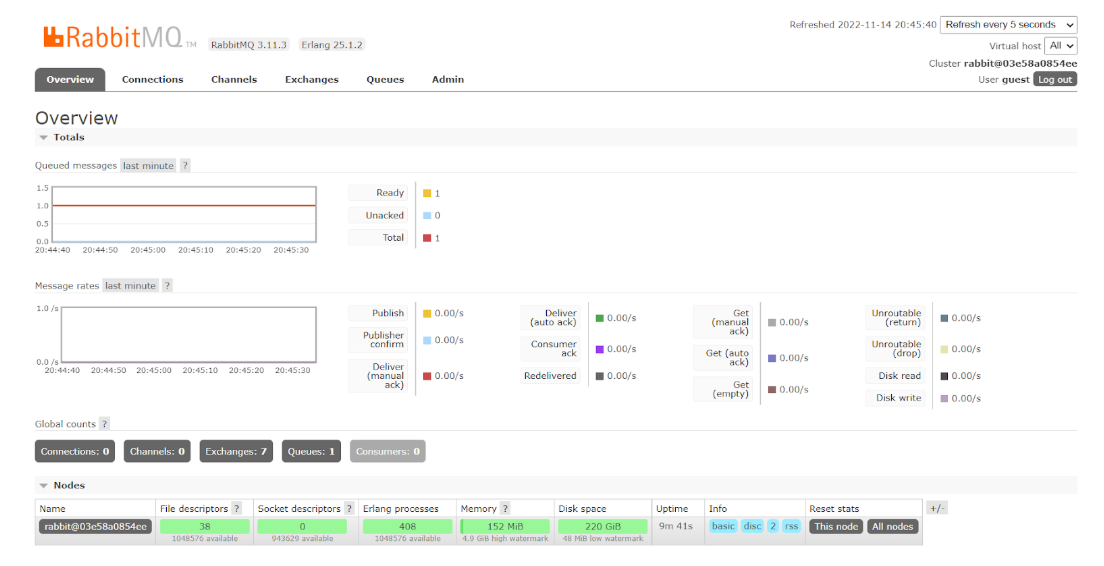

Сейчас мы не будем использовать графический интерфейс, однако вы можете познакомиться с ним здесь. https://www.cloudamqp.com/blog/part3-rabbitmq-for-beginners_the-management-interface.html

**Шаг 3.** Установка библиотеки pika.

Установим её через pip-команду, сразу зафиксировав нужную нам версию (1.1.0).

In [ ]:
#pip install pika==1.1.0

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\tgorbunov\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


Итак, всё готово к работе. Давайте обсудим план наших действий.

### Чем будем заниматься?

Мы реализуем несколько сервисов:

- Первый будет отправлять признаки в одну очередь и истинный ответ — в другую.
- Второй сервис будет читать признаки, делать предсказание и отправлять его в очередь с предсказаниями.
- Третий сервис будет читать очереди с истинными ответами и предсказаниями.

Схематично описанную архитектуру можно представить в следующем виде:

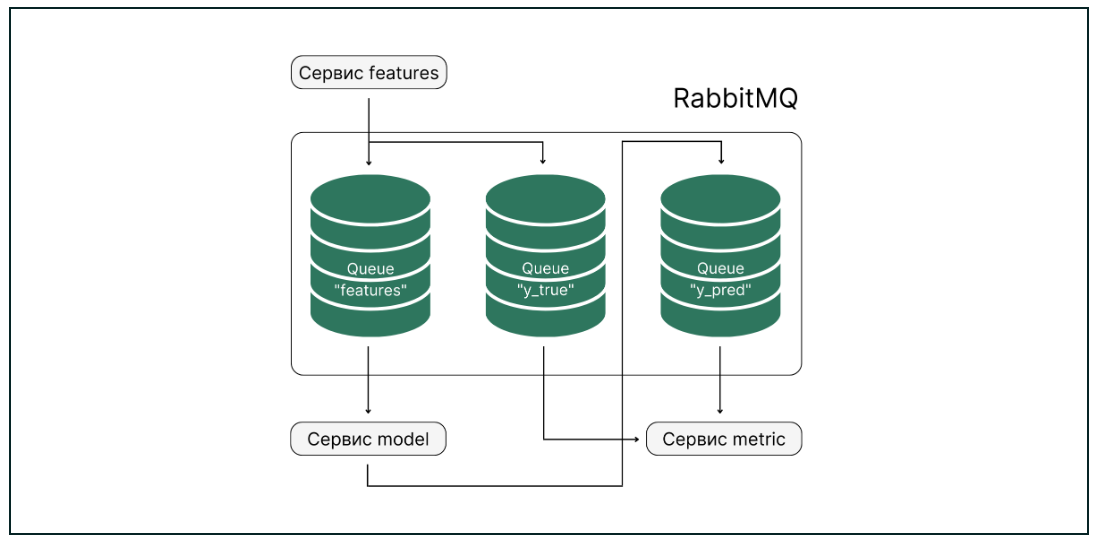

Давайте заранее организуем директорию нашего проекта. Это нужно для дальнейшего удобства, когда мы будем помещать каждый из сервисов в отдельный контейнер.

Рабочую папку проекта назовём microservice_architecture. В этой папке будут три другие папки: features, model и metric. Внутри каждой из этих папок будет по папке src, в которой хранится исходный код для каждого сервиса: features.py, model.py и metric.py. Также в папке model/src/ будет находиться файл с сериализованной моделью — что это за модель, мы посмотрим чуть позже.

In [ ]:
microservice_architecture
    └─features
        └─src
            └─features.py
    └─model
        └─src
            └─model.py
            └─myfile.pkl
    └─metric
        └─src
            └─metric.py

После создания рабочей директории можно переходить к разработке самих микросервисов.

### СЕРВИС I. СЕРВИС ОТПРАВКИ ПРИЗНАКОВ

Приступим к созданию первого сервиса — сервиса для отправки признаков в одну очередь, а истинных ответов — в другую.

Создадим файл features/src/features.py, в котором будем реализовывать сервис. Этот сервис будет брать случайную строку из датасета и отправлять полученные признаки объекта в очередь.